The project aims to predict individual medical insurance costs based on personal characteristics. The data contains information about health insurance beneficiaries  and the medical costs billed by their insurance. The data was loaded and there was no missing value. The duplicate was removed because it was only one  which was believed to be a data entry error because the  features and target were thesame. One-hot-encoding was used  to convert the object ( sex, smoker, region) to numbers , which transformed the features because machine learning understands numbers. The features, target, and valid were normalized to avoid large values dominating the learning process and ensure consistency. The model has 4 layers starting with 128 neurons. The batch normailzation was used, the dropout  was 30%, Early stopping was used to know when to stop training. The model can predict insurance chares. The actual and predicted insurance charges almost the same, positively correlated wih r square of 0.8505. This shows cheapercases are cheaper and expensive cases àre expensive.

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_absolute_error



In [2]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/TripleTen-DS/Dataset/refs/heads/main/insurance.csv')

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
df.shape

(1338, 7)

In [7]:
df.duplicated().sum()

1

In [8]:
duplicated_row = df[df.duplicated(keep=False)]
print(duplicated_row)

     age   sex    bmi  children smoker     region    charges
195   19  male  30.59         0     no  northwest  1639.5631
581   19  male  30.59         0     no  northwest  1639.5631


In [9]:
df_clean = df.drop_duplicates().reset_index(drop=True)

In [10]:
df_clean.shape

(1337, 7)

In [11]:
df_clean_ohe = pd.get_dummies(df_clean, drop_first=True)

In [12]:
target = df_clean_ohe['charges']
features = df_clean_ohe.drop('charges', axis=1)
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.20, random_state=12345
)

print(features_train.shape)
print(features_test.shape)
print(target_train.shape)
print(target_test.shape)


(1069, 8)
(268, 8)
(1069,)
(268,)


In [13]:
# spliting the test into half

features_test, features_valid, target_test, target_valid = train_test_split(features_test, target_test, test_size =0.5, random_state =12345)
print(features_test.shape)
print(features_valid.shape)
print(target_test.shape)
print(target_valid.shape)

(134, 8)
(134, 8)
(134,)
(134,)


In [14]:

scaler = StandardScaler()

numerical_features = ['age', 'bmi','children']
features_train_scaled = features_train.copy()
features_test_scaled = features_test.copy()


features_train_scaled[numerical_features] = scaler.fit_transform(features_train[numerical_features])
features_test_scaled[numerical_features] = scaler.transform(features_test[numerical_features])



In [15]:

print("Before normalization:")
print(features_train[numerical_features].describe())

print("\nAfter normalization:")
print(features_train_scaled[numerical_features].describe())


Before normalization:
               age          bmi     children
count  1069.000000  1069.000000  1069.000000
mean     39.204864    30.600566     1.095416
std      13.926443     6.043326     1.209462
min      18.000000    15.960000     0.000000
25%      27.000000    26.180000     0.000000
50%      39.000000    30.210000     1.000000
75%      51.000000    34.430000     2.000000
max      64.000000    53.130000     5.000000

After normalization:
                age           bmi      children
count  1.069000e+03  1.069000e+03  1.069000e+03
mean  -6.646798e-17 -4.353653e-16  6.979138e-17
std    1.000468e+00  1.000468e+00  1.000468e+00
min   -1.523346e+00 -2.423735e+00 -9.061296e-01
25%   -8.767908e-01 -7.318213e-01 -9.061296e-01
50%   -1.471734e-02 -6.465789e-02 -7.892846e-02
75%    8.473561e-01  6.339599e-01  7.482727e-01
max    1.781269e+00  3.729731e+00  3.229876e+00


In [16]:

target_scaler = StandardScaler()

target_train_scaled = pd.Series(
    target_scaler.fit_transform(target_train.values.reshape(-1, 1)).flatten(),
    index=target_train.index
)
target_test_scaled = pd.Series(
    target_scaler.transform(target_test.values.reshape(-1, 1)).flatten(),
    index=target_test.index
)

In [17]:

print("Target scaling verification:")
print(f"Original target_train mean: {target_train.mean():.2f}")
print(f"Scaled target_train mean: {target_train_scaled.mean():.3f}")
print(f"Scaled target_train std: {target_train_scaled.std():.3f}")
print(f"Scaled target_test mean: {target_test_scaled.mean():.3f}")

Target scaling verification:
Original target_train mean: 13268.01
Scaled target_train mean: -0.000
Scaled target_train std: 1.000
Scaled target_test mean: -0.085


In [18]:
valid_scaler = StandardScaler()
features_valid_scaled = features_valid.copy()
features_valid_scaled[numerical_features] = scaler.transform(features_valid[numerical_features])

# Scale validation targets
target_valid_scaled = pd.Series(
    target_scaler.transform(target_valid.values.reshape(-1,1)).flatten(),index = target_valid.index)

In [19]:
# Build the complete model
n_features = 8

# Complete model from Task 3
model = Sequential()
model.add(Dense(128, activation='relu', kernel_initializer=HeNormal(),
                kernel_regularizer=l2(0.001), input_shape=(8,)))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu', kernel_initializer=HeNormal(),
                kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu', kernel_initializer=HeNormal(),
                kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(1, activation='linear'))

# TODO: Compile the model for binary classification
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# TODO: Set up early stopping
# - Monitor validation loss
# - Stop if no improvement for 10 epochs (patience)
# - Restore weights from best epoch
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)


model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               1152      
                                                                 
 batch_normalization (BatchN  (None, 128)              512       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 batch_normalization_1 (Batc  (None, 64)               256       
 hNormalization)                                                 
                                                                 
 dropout_1 (Dropout)         (None, 64)                0

2026-02-03 19:38:45.068633: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [20]:


history = model.fit(
    features_train_scaled, target_train_scaled,
    validation_data=(features_valid_scaled, target_valid_scaled),
    epochs=200,
    batch_size=32,
    callbacks=early_stopping
)




Epoch 1/200
34/34 [==============================] - 1s 6ms/step - loss: 2.9852 - mae: 1.2198 - val_loss: 1.2462 - val_mae: 0.7635
Epoch 2/200
34/34 [==============================] - 0s 2ms/step - loss: 2.2182 - mae: 1.0195 - val_loss: 0.9456 - val_mae: 0.5694
Epoch 3/200
34/34 [==============================] - 0s 2ms/step - loss: 1.7636 - mae: 0.8898 - val_loss: 0.8505 - val_mae: 0.4763
Epoch 4/200
34/34 [==============================] - 0s 2ms/step - loss: 1.4391 - mae: 0.7792 - val_loss: 0.7995 - val_mae: 0.4423
Epoch 5/200
34/34 [==============================] - 0s 2ms/step - loss: 1.4883 - mae: 0.7913 - val_loss: 0.7276 - val_mae: 0.3922
Epoch 6/200
34/34 [==============================] - 0s 2ms/step - loss: 1.3725 - mae: 0.7589 - val_loss: 0.6792 - val_mae: 0.3495
Epoch 7/200
34/34 [==============================] - 0s 2ms/step - loss: 1.2757 - mae: 0.7038 - val_loss: 0.6556 - val_mae: 0.3306
Epoch 8/200
34/34 [==============================] - 0s 2ms/step - loss: 1.1589 - m

The model make predictions in batches of 32. And repeats up to 200 epochs. This shows how the model's performance improved over time. Epoch 150 is the lowest with Val_loss = 0.2141  which makes it the bes valization loss.The model start overfitting at 151.

In [21]:
predictions_scaled = model.predict(features_test_scaled)
print(f"Predictions Shape:{predictions_scaled.shape}")


Predictions Shape:(134, 1)


In [22]:
predictions_original = target_scaler.inverse_transform(predictions_scaled).flatten()
actual_original = target_test.values
print(f"Prediction range: ${predictions_original.min():.2f} - ${predictions_original.max():.2f}")
print(f"Actual range: ${actual_original.min():.2f} - ${actual_original.max():.2f}")

Prediction range: $1687.16 - $48215.20
Actual range: $1141.45 - $47928.03


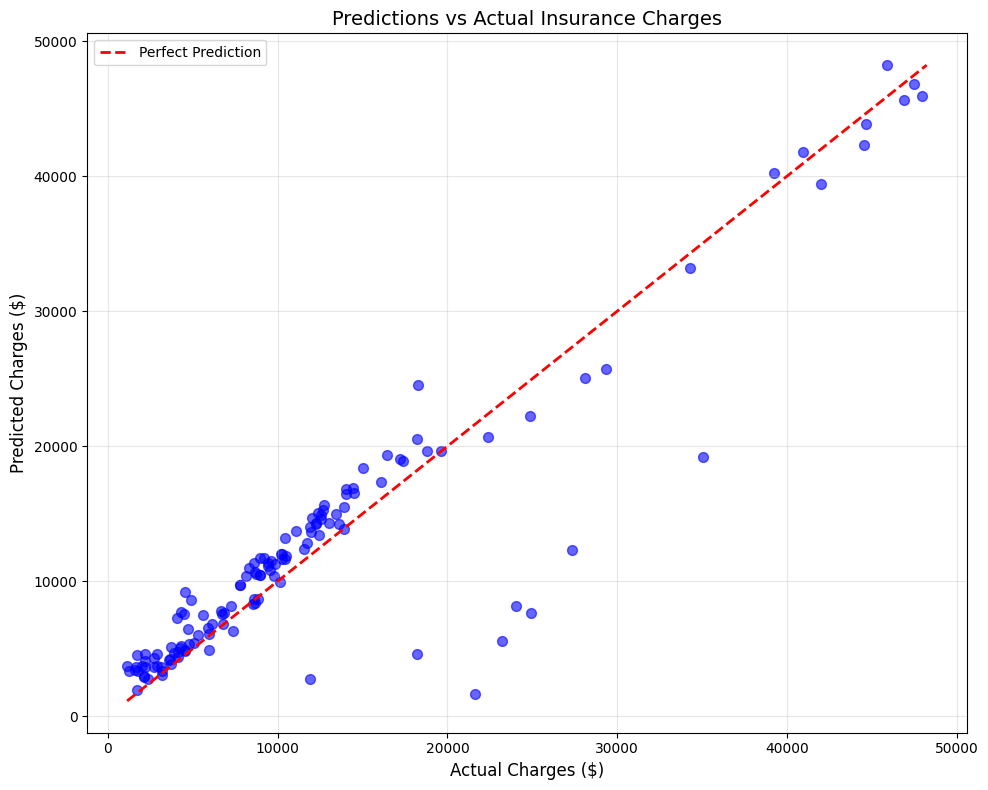

In [23]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 8))

# Create scatter plot
plt.scatter(actual_original, predictions_original, alpha=0.6, color='blue', s=50)

# Add perfect prediction line (diagonal)
min_val = min(actual_original.min(), predictions_original.min())
max_val = max(actual_original.max(), predictions_original.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

# Formatting
plt.xlabel('Actual Charges ($)', fontsize=12)
plt.ylabel('Predicted Charges ($)', fontsize=12)
plt.title('Predictions vs Actual Insurance Charges', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
r2 = r2_score(actual_original, predictions_original)
print(f"R² Score: {r2:.4f}")

R² Score: 0.8488


The plot shows the dots are tightly clustered around the red line, shows the prediction and actual are almost same. The R2 score is 0.8505 which is an excellent performance for the predictive model which shows that the neural network has learnt Age, BMI, smoking status , number of children and region. So the model can predict insurance cost.

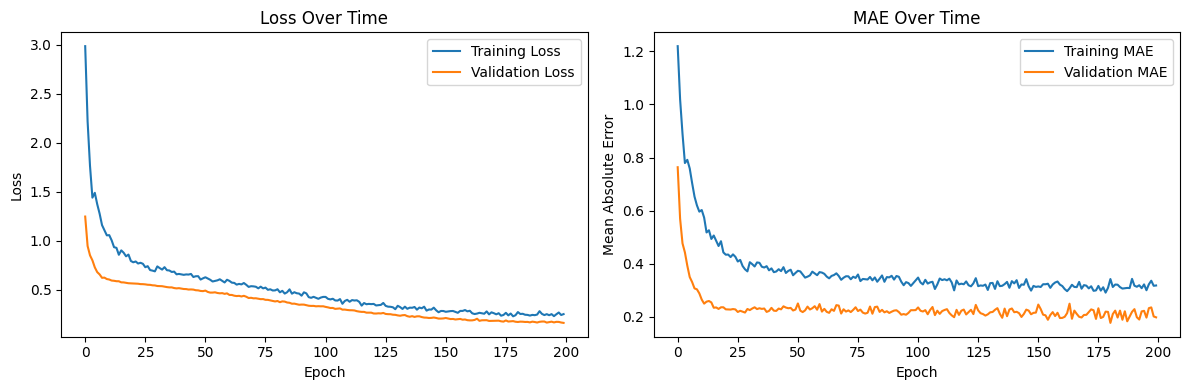

In [25]:


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Over Time')

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.title('MAE Over Time')

plt.tight_layout()  # Prevents overlap
plt.show()




The training and validation loss decresses over time as model learns . The gap between the two lines is small which means there is no overfitting.  

The MAE, which shows both training and validation are decreasing over time

SUMMARY

The data was loaded and there was no missing value. The duplicate was removed because it was only one which was believed to be a data entry error because the features and target were thesame. One-hot-encoding was used to convert the object ( sex, smoker, region) to numbers , which transformed the features because machine learning understands numbers. The features, target, and valid were normalized to avoid large values dominating the learning process and ensure consistency. The model has 4 layers starting with 128 neurons. The batch normailzation was used, the dropout was 30%, Early stopping was used to know when to stop training.

The model make predictions in batches of 32. And repeats up to 200 epochs. This shows how the model's performance improved over time. Epoch 150 is the lowest with Val_loss = 0.2141 which makes it the bes valization loss.The model start overfitting at 151.
The actual and predictions of he insurance charges are almost the same. The predictions and actal insurance costs are strongly positive related.  The R square is 0.8505 which is very strong correlation, consistent and predictable. The model can predict the insurance cost. 
High-risk individuals (smokers, older age, higher BMI) has Higher predicted AND actual costs
Low-risk individuals (non-smokers, younger, healthy BMI) → Lower predicted AND actual costs
It correctly identifies expensive cases as expensive and cheaper cases as cheaper.




